In [38]:
import torch
import json
from scripts.my_train import parse_args, build_model, get_optimizer
from cs336_basics.my_data_utils import my_load_checkpoint
from tokenizers import Tokenizer

In [39]:

@torch.no_grad()
def generate_text(model, tokenizer, prompt_text, max_new_tokens=50, temperature=1.0, top_k=50, device="cpu"):
    # 编码提示
    enc = tokenizer.encode(prompt_text)
    input_ids = torch.tensor(enc.ids, device=device, dtype=torch.long).unsqueeze(0)  # [1, T]
    eos_id = tokenizer.token_to_id("<|endoftext|>")

    for _ in range(max_new_tokens):
        logits = model(input_ids)  # 期望输出形状 [B, T, V]
        next_logits = logits[:, -1, :] / max(temperature, 1e-6)
        # top-k 过滤
        if top_k is not None and top_k > 0:
            values, _ = torch.topk(next_logits, k=min(top_k, next_logits.size(-1)))
            min_keep = values[:, -1].unsqueeze(-1)
            next_logits = torch.where(next_logits < min_keep, torch.full_like(next_logits, -float("inf")), next_logits)
        probs = torch.softmax(next_logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1)  # [1,1]
        input_ids = torch.cat([input_ids, next_id], dim=1)
        if eos_id is not None and next_id.item() == eos_id:
            break

    return tokenizer.decode(input_ids[0].tolist(), skip_special_tokens=False)



In [40]:
args = parse_args([])

In [41]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = build_model(args,dtype=torch.float32,device=device)

optimizer = get_optimizer(model, args)
my_load_checkpoint("../my_models/TinyStories_17M_autodl.pt", model, optimizer)
print("Model loaded successfully")

tok = Tokenizer.from_file("../hf_tokenizer/tinystories/tokenizer.json")
prompt = "Once upon a time"
generated = generate_text(
    model,
    tok,
    prompt_text=prompt,
    max_new_tokens=200,
    temperature=1.0,
    top_k=40,
    device=device,
)
print("\n--- Generated ---")
print(generated)


Model loaded successfully

--- Generated ---
Once upon a time, in a small town, there was a unique dog named Spot. Spot loved to play with his toy, a big red ball. He would throw the ball and try to catch it. One day, while playing, he saw a big red ball start to bounce on the ball.
Spot was very excited and ran to get the ball. As he played, he met a little boy named Tim. Tim said, "Hey, that's my big ball! Give it back!" Spot didn't want to give the ball back to Tim. He was cold, so he decided to give the ball to Tim.
Tim saw Spot and smiled. He said, "Thank you, Spot! You are a very good friend." Spot felt happy that he could help his new friend. From that day on, Tim and Spot played together every day at the park. They were both very lucky to have each other as friends.
<|endoftext|>


In [42]:
model

TransformerLanguageModel(
  (emb): Embedding()
  (blocks): ModuleList(
    (0-3): 4 x TransformerBlock(
      (rms1): RMSNorm()
      (rms2): RMSNorm()
      (mhsa): MultiHeadSelfAttention(
        (linear_Wq): Linear()
        (linear_Wk): Linear()
        (linear_Wv): Linear()
        (linear_Wo): Linear()
        (rope): RotaryPositionalEmbedding()
      )
      (ffn): SwiGLUFFN(
        (linear1): Linear()
        (linear2): Linear()
        (linear3): Linear()
      )
    )
  )
  (out_norm): RMSNorm()
  (head): Linear()
)

In [43]:
import torch
import math
import matplotlib.pyplot as plt
import seaborn as sns
from einops import rearrange
from cs336_basics import my_module  # 假设你的源码文件名为 my_module.py

# 1. 准备一个全局容器来接收 Attention Map
# 结构: List[Tensor], 下标即为层数 (0, 1, 2...)
# 每个 Tensor 的形状应该是 (batch_size, num_heads, seq_len, seq_len)
captured_attentions = []

# 2. 定义原本函数的备份（运行完记得恢复）
original_sdpa = my_module.scaled_dot_product_attention

# 3. 定义“间谍”函数 (Hooked Function)
# 它的签名必须和原函数完全一致
def hooked_scaled_dot_product_attention(Q, K, V, mask=None):
    d_k = Q.shape[-1]
    
    # 复刻原函数的计算逻辑
    # 使用 torch.einsum 替代 einops 以减少依赖，效果是一样的
    scaled_prod = torch.einsum("... q d, ... k d -> ... q k", Q, K) / math.sqrt(d_k)
    
    if mask is not None:
        # 这里的 mask 逻辑要和原代码一致
        scaled_prod.masked_fill_(~mask, -float('inf'))

    # 计算注意力权重 (Attention Weights)
    probs = torch.softmax(scaled_prod, dim=-1)
    
    # === 关键步骤：把权重 detach 出来存进全局列表 ===
    # 我们将其移到 CPU 以免爆显存
    captured_attentions.append(probs.detach().cpu())
    
    # 继续完成原本的计算流程
    res = torch.einsum("... q k, ... k v -> ... q v", probs, V)
    return res

print("准备就绪。")

准备就绪。


In [51]:
# === 修改开始 ===
# 1. 构造一个诱导性的 Prompt (使用真实文本重复)
# 选取一段符合 TinyStories 风格的简单文本
# text_segment = "Amy has big pretty eyes. "
# 将其重复两次，制造 [A] ... [A] 的模式
# full_text = text_segment * 3
full_text = "Amy has big pretty eyes. Amy has big pretty eyes. Amy has big pretty eyes."

print(f"Input Text: {full_text}")

# 2. 使用 tok 进行分词
# tok.encode(str) 通常返回一个 Encoding 对象，包含 .ids 属性
encoded = tok.encode(full_text)
token_ids = encoded.ids

# 转换为 PyTorch Tensor 并增加 batch 维度 -> (1, seq_len)
input_tokens = torch.tensor([token_ids], dtype=torch.long)

# 检查长度是否超过模型的最大上下文限制 (context_length)
# 假设 model.blocks[0].max_seq_len 存有最大长度
max_len = model.blocks[0].max_seq_len
if input_tokens.shape[1] > max_len:
    print(f"Warning: 文本过长 ({input_tokens.shape[1]}), 截断到 {max_len}")
    input_tokens = input_tokens[:, :max_len]

# 移动到正确的设备
device = next(model.parameters()).device
input_tokens = input_tokens.to(device)

# 为了后续画图能显示单词，我们需要把 id 转回 string 列表
# tok.id_to_token(id) 或 tok.decode([id])
tokens_labels = [tok.decode([i]) for i in input_tokens[0].tolist()]
# === 修改结束 ===

# 2. 开始劫持 (Monkey Patch)
my_module.scaled_dot_product_attention = hooked_scaled_dot_product_attention
captured_attentions = [] # 清空缓存

# 3. 运行模型 (Forward Pass)
# 只需要做一次前向传播，中间的 attention map 就会被自动记录
with torch.no_grad():
    model(input_tokens)

# 4. 恢复原函数 (解除劫持)
my_module.scaled_dot_product_attention = original_sdpa

print(f"已捕获 {len(captured_attentions)} 层的注意力图。")
print(f"每层形状: {captured_attentions[0].shape}") 
# 预期形状: (1, num_heads, seq_len, seq_len)

Input Text: Amy has big pretty eyes. Amy has big pretty eyes. Amy has big pretty eyes.
已捕获 4 层的注意力图。
每层形状: torch.Size([1, 16, 18, 18])


开始绘制...


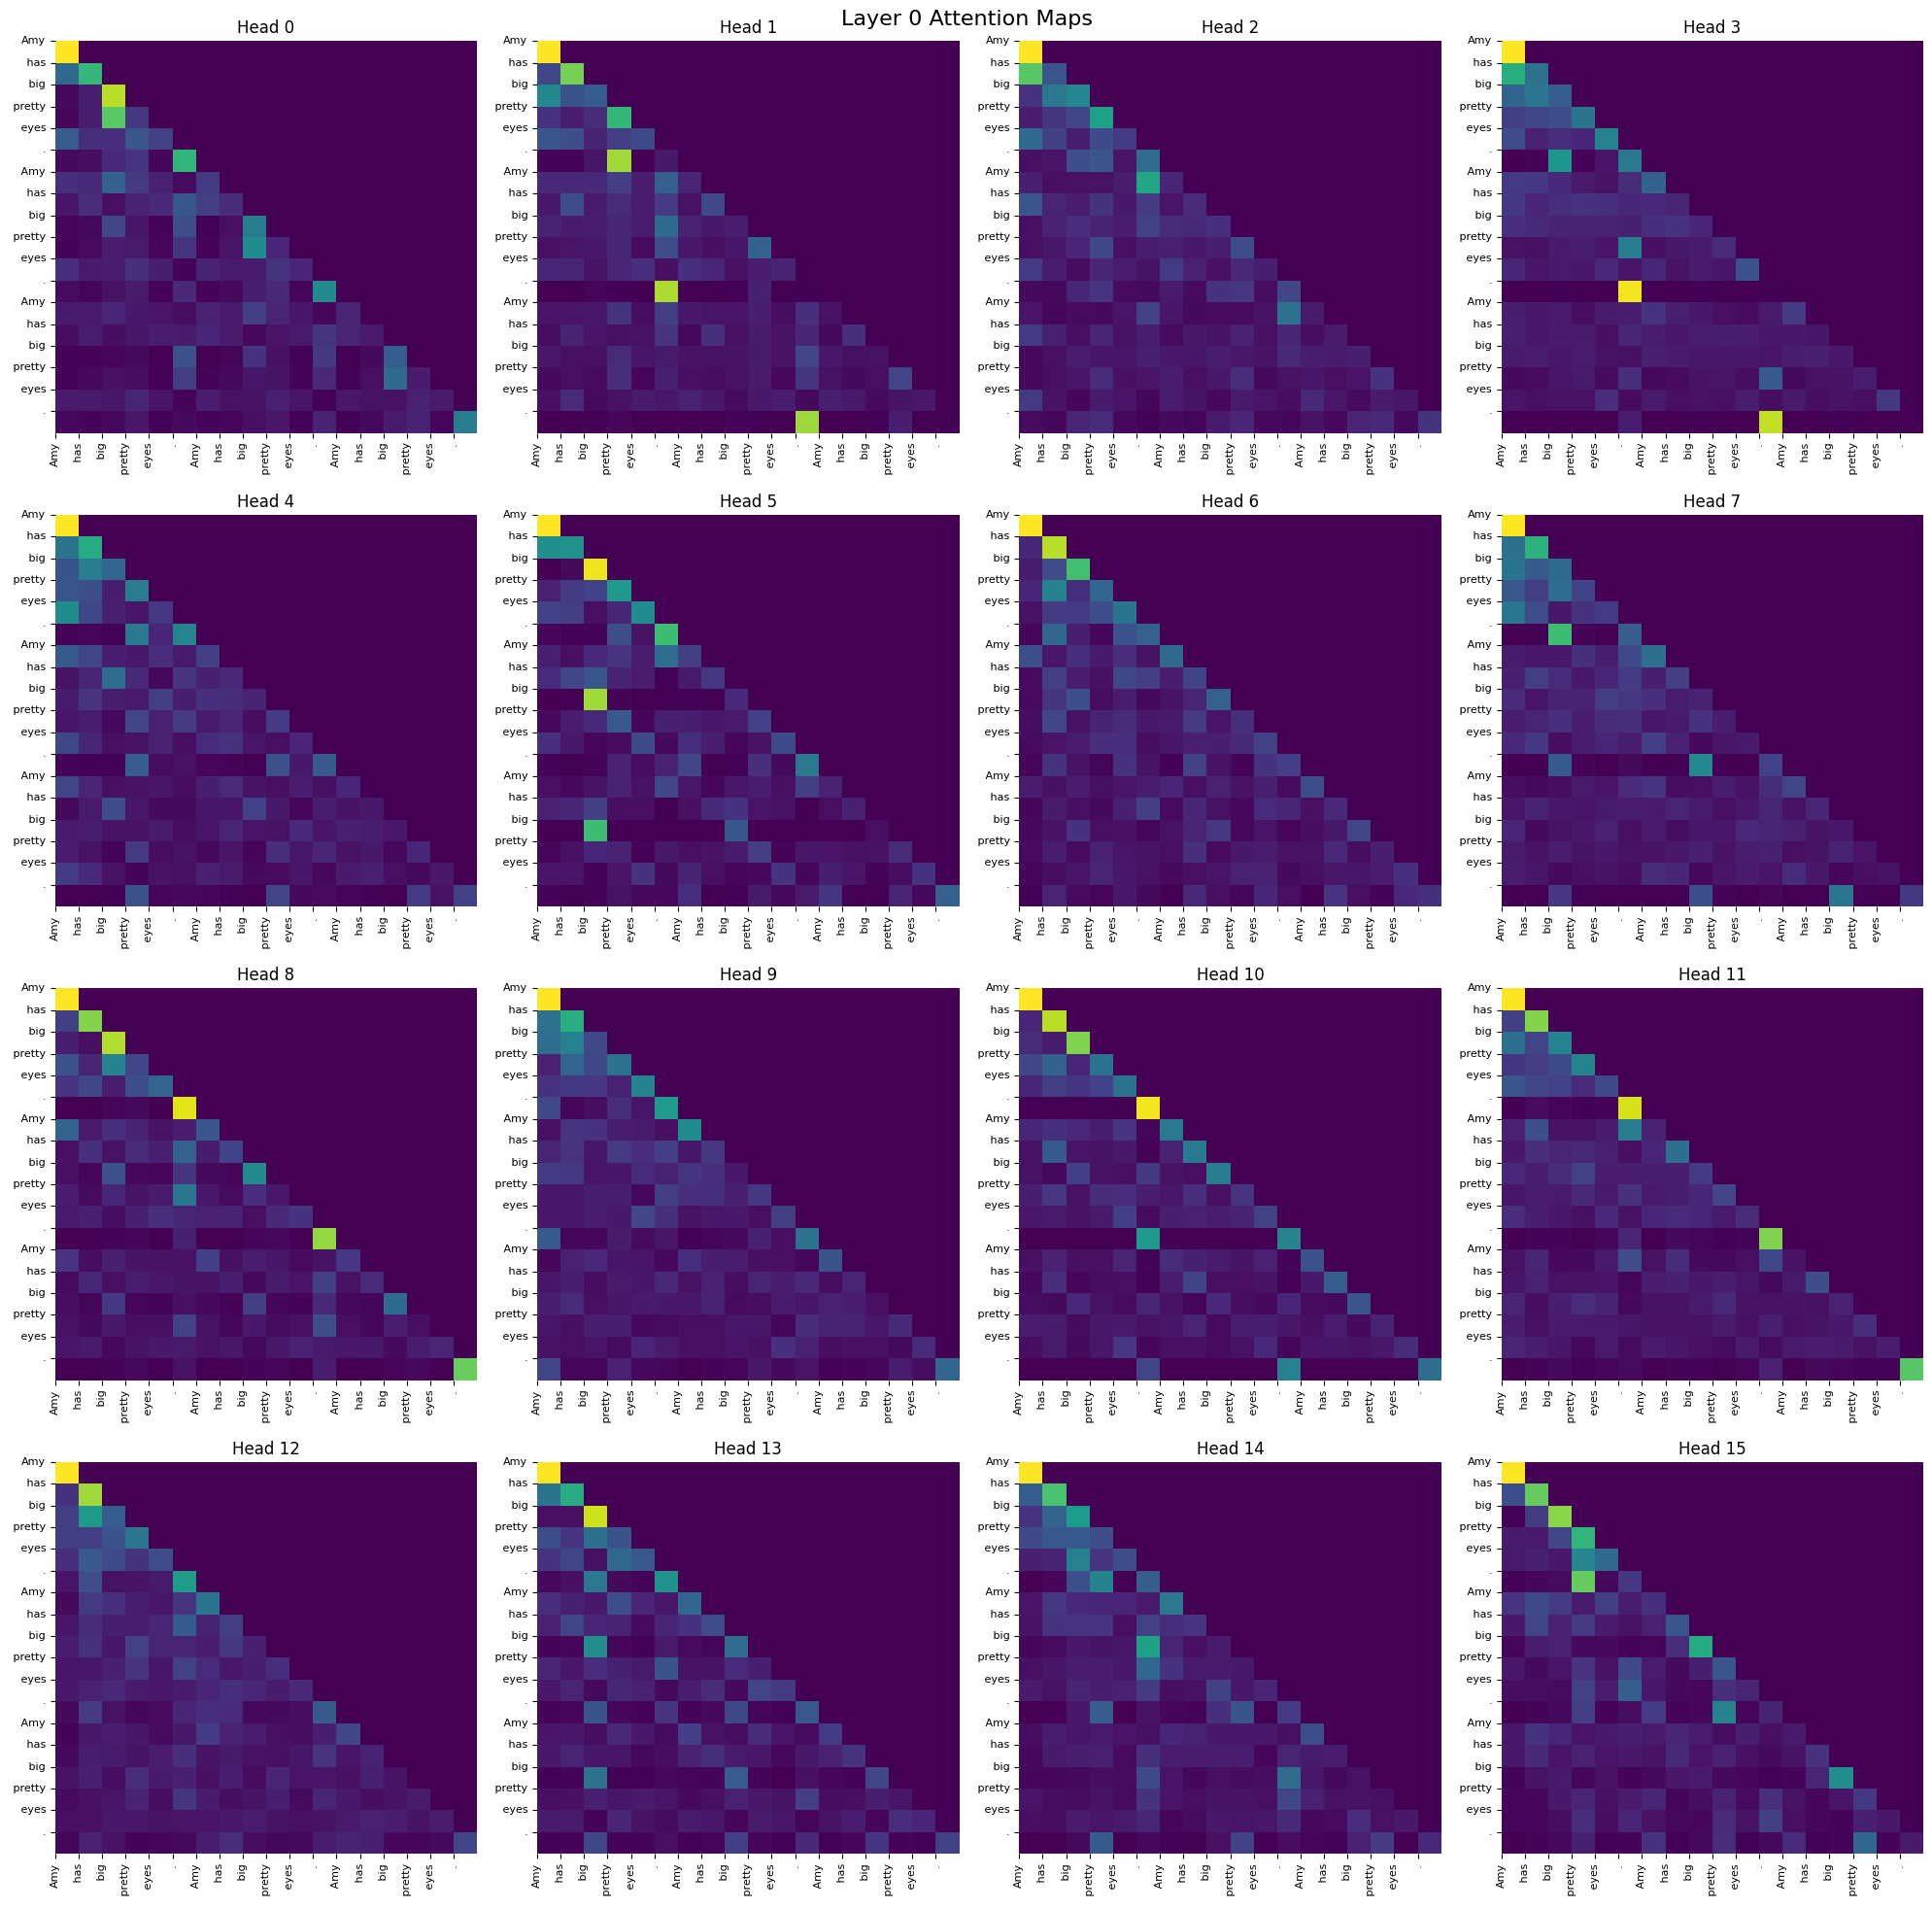

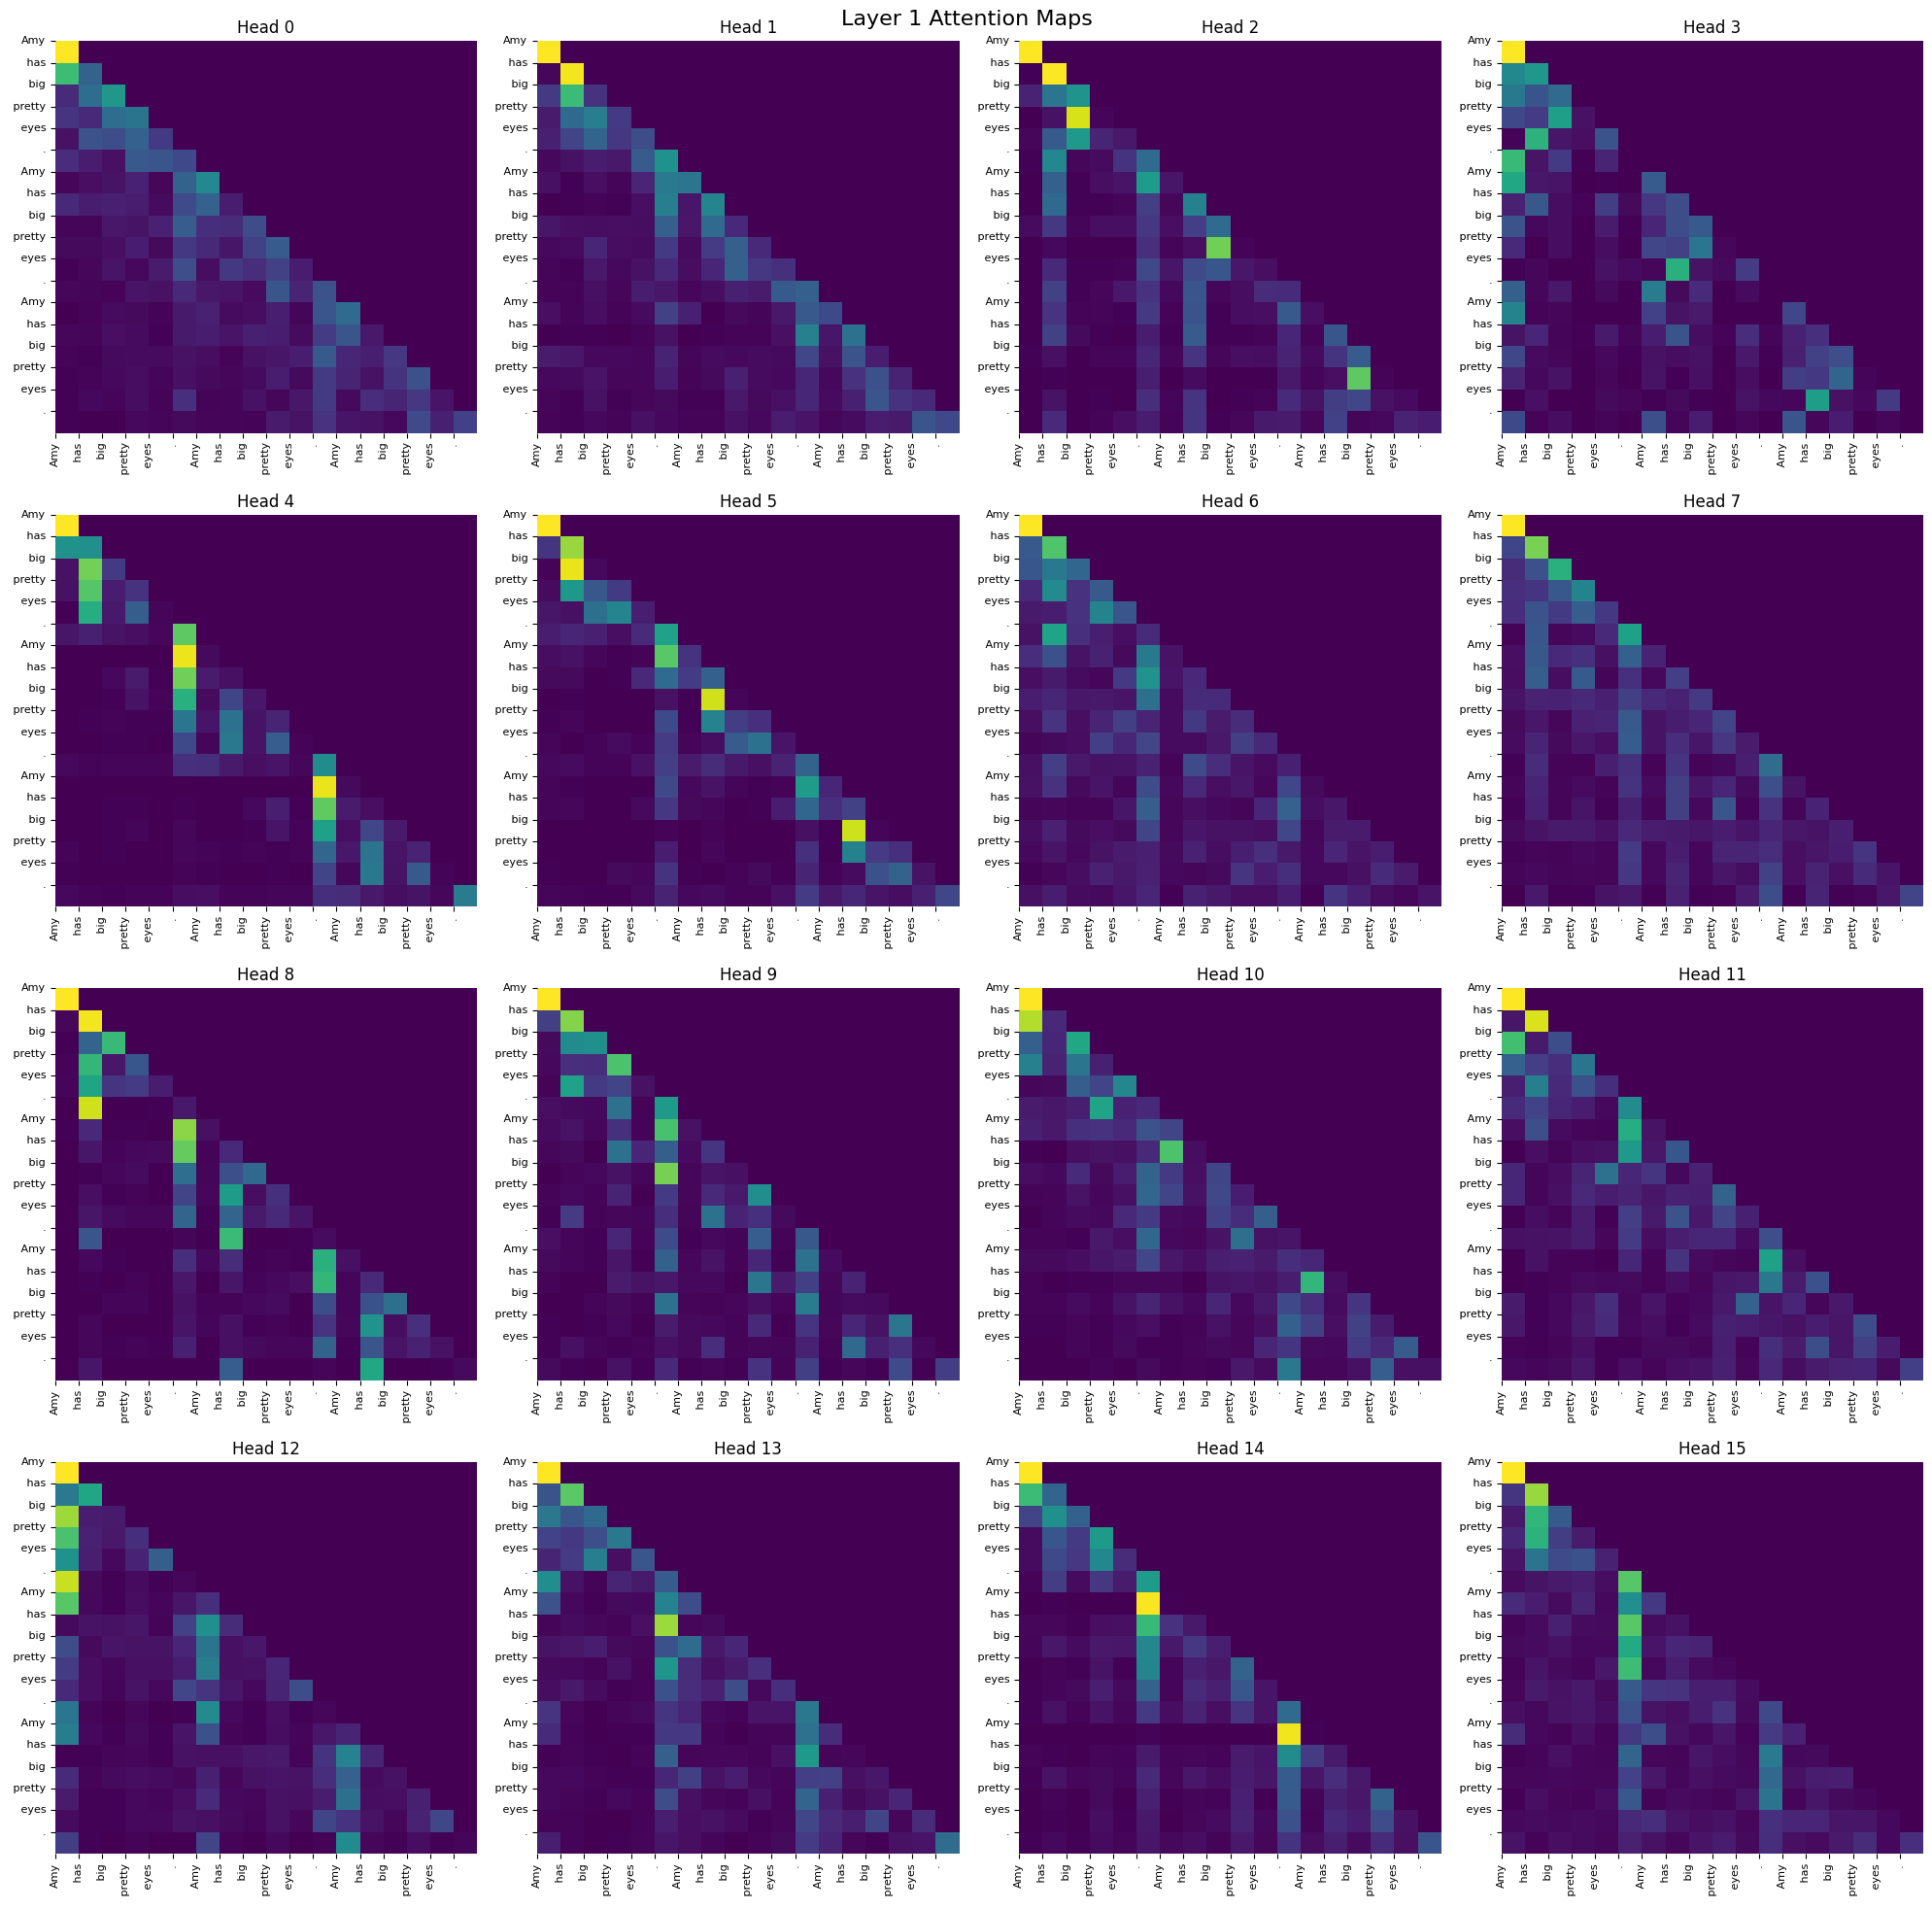

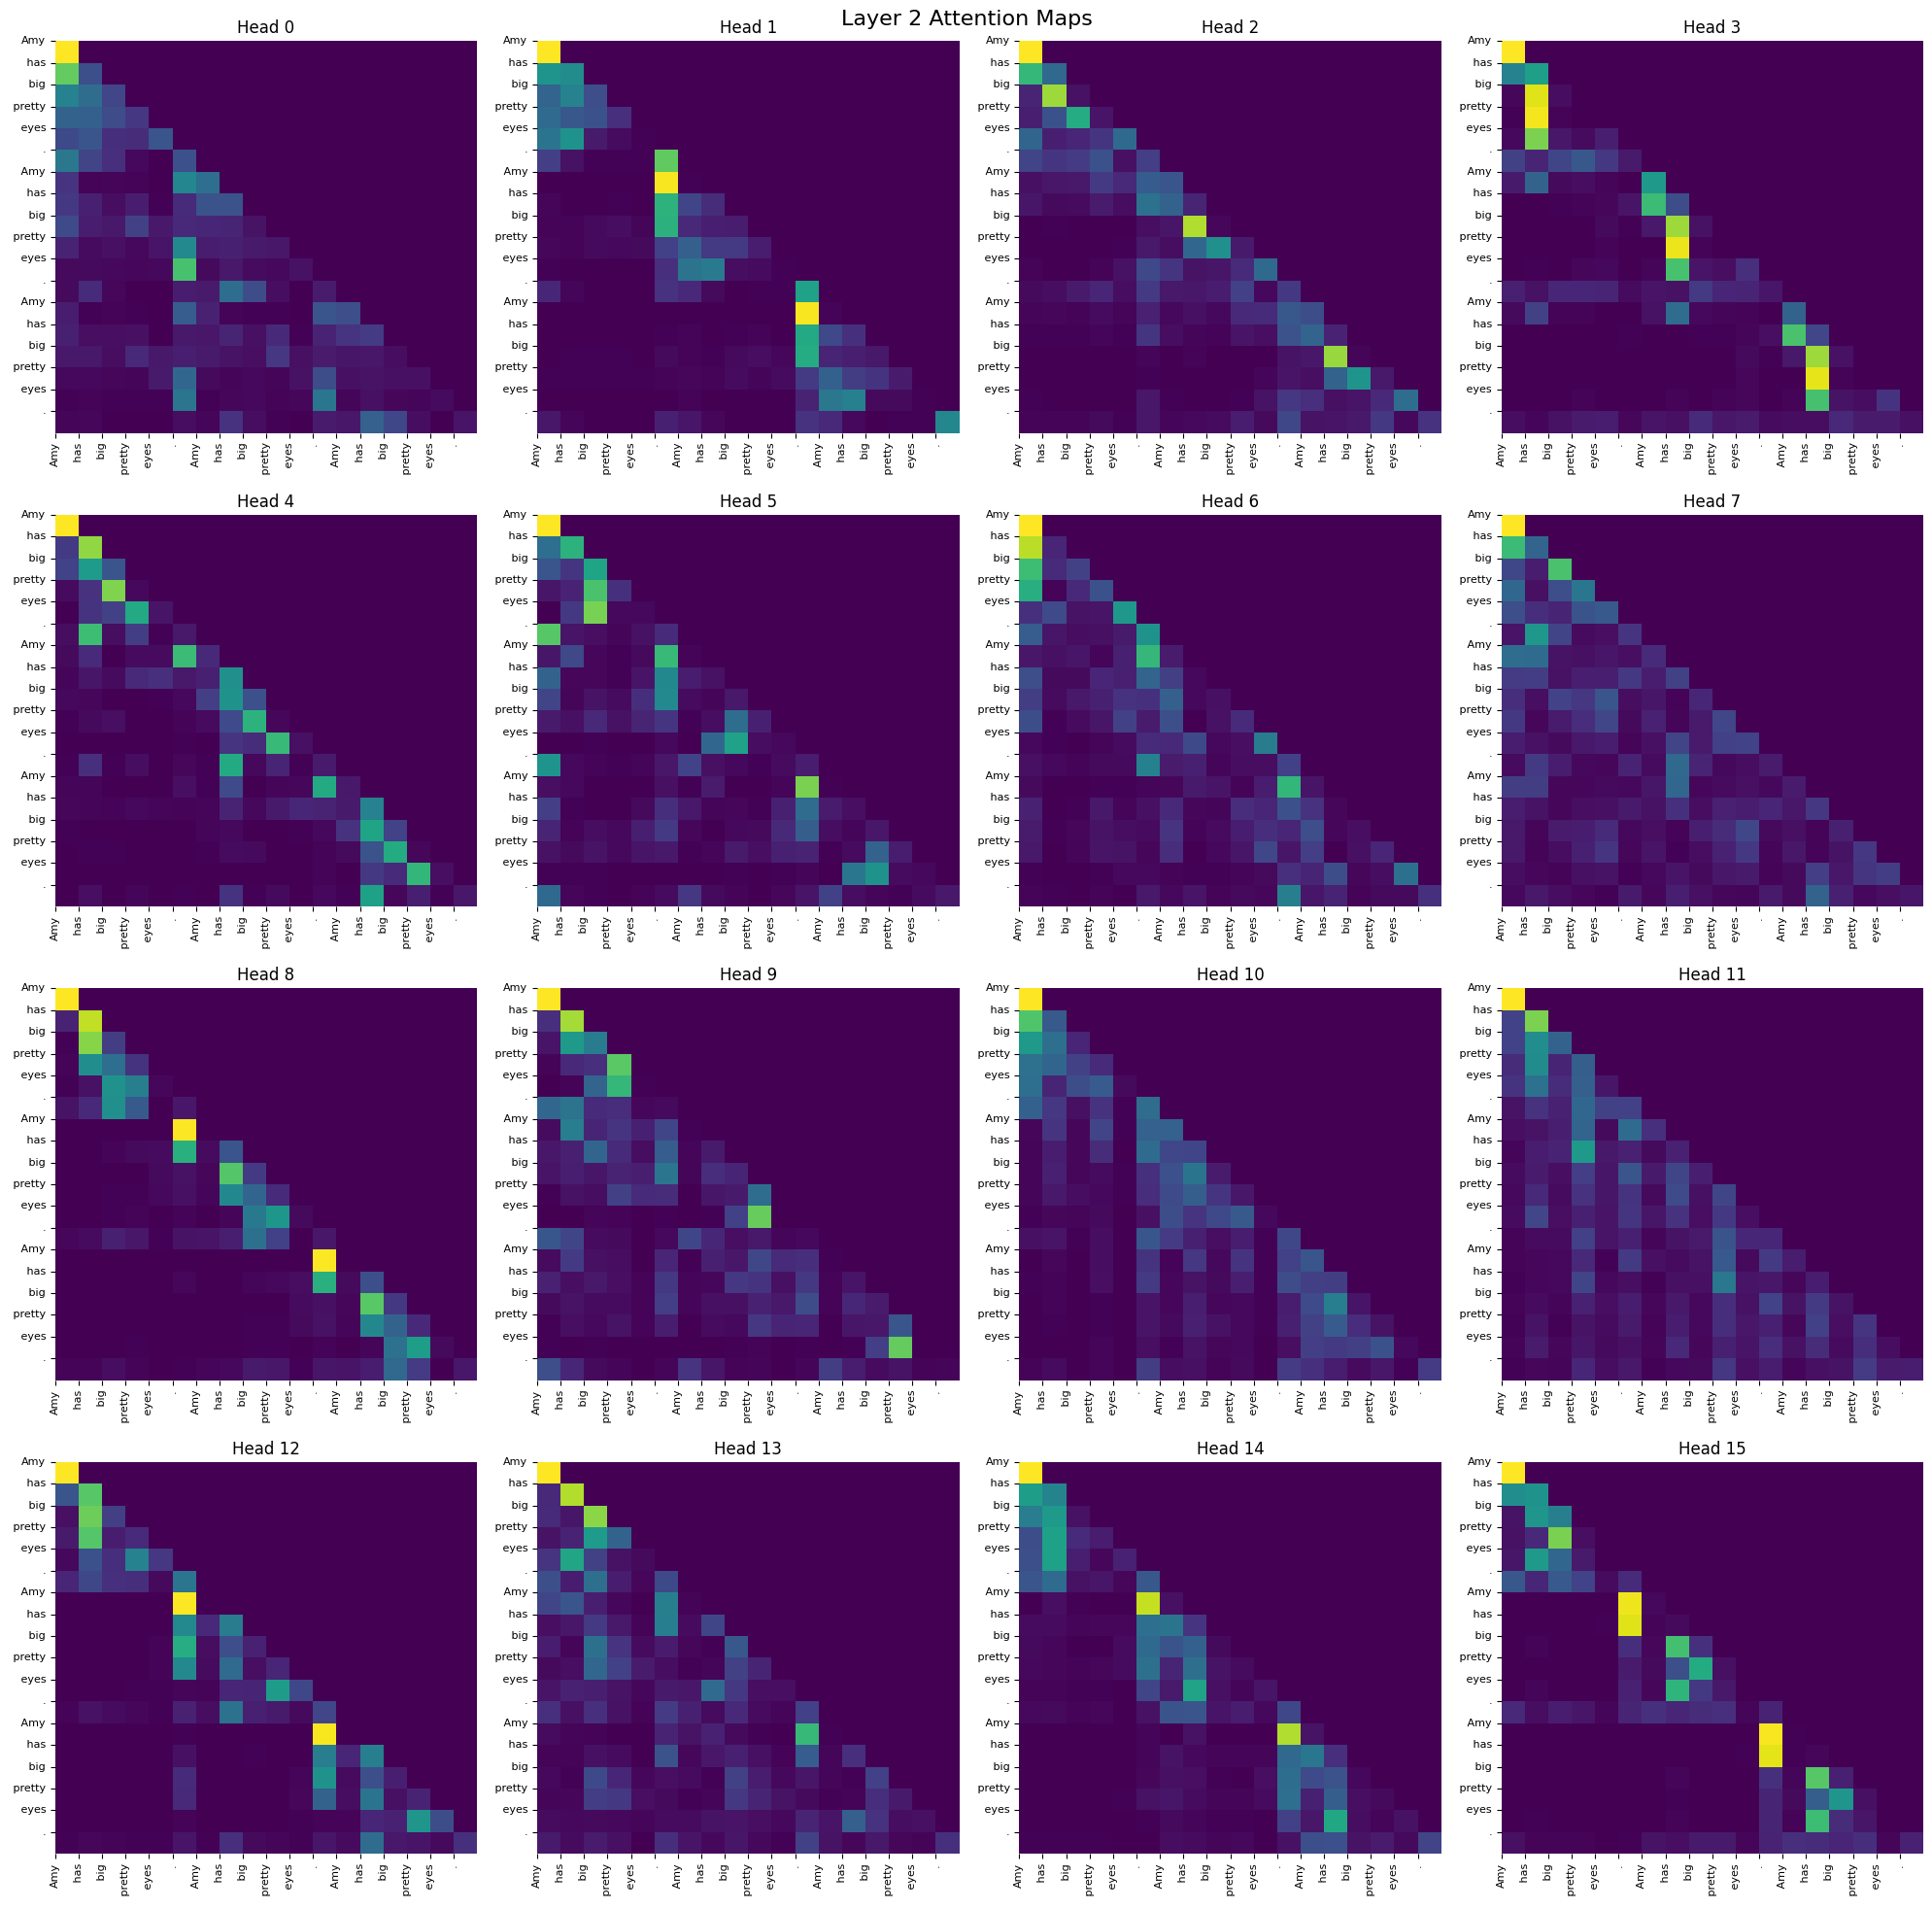

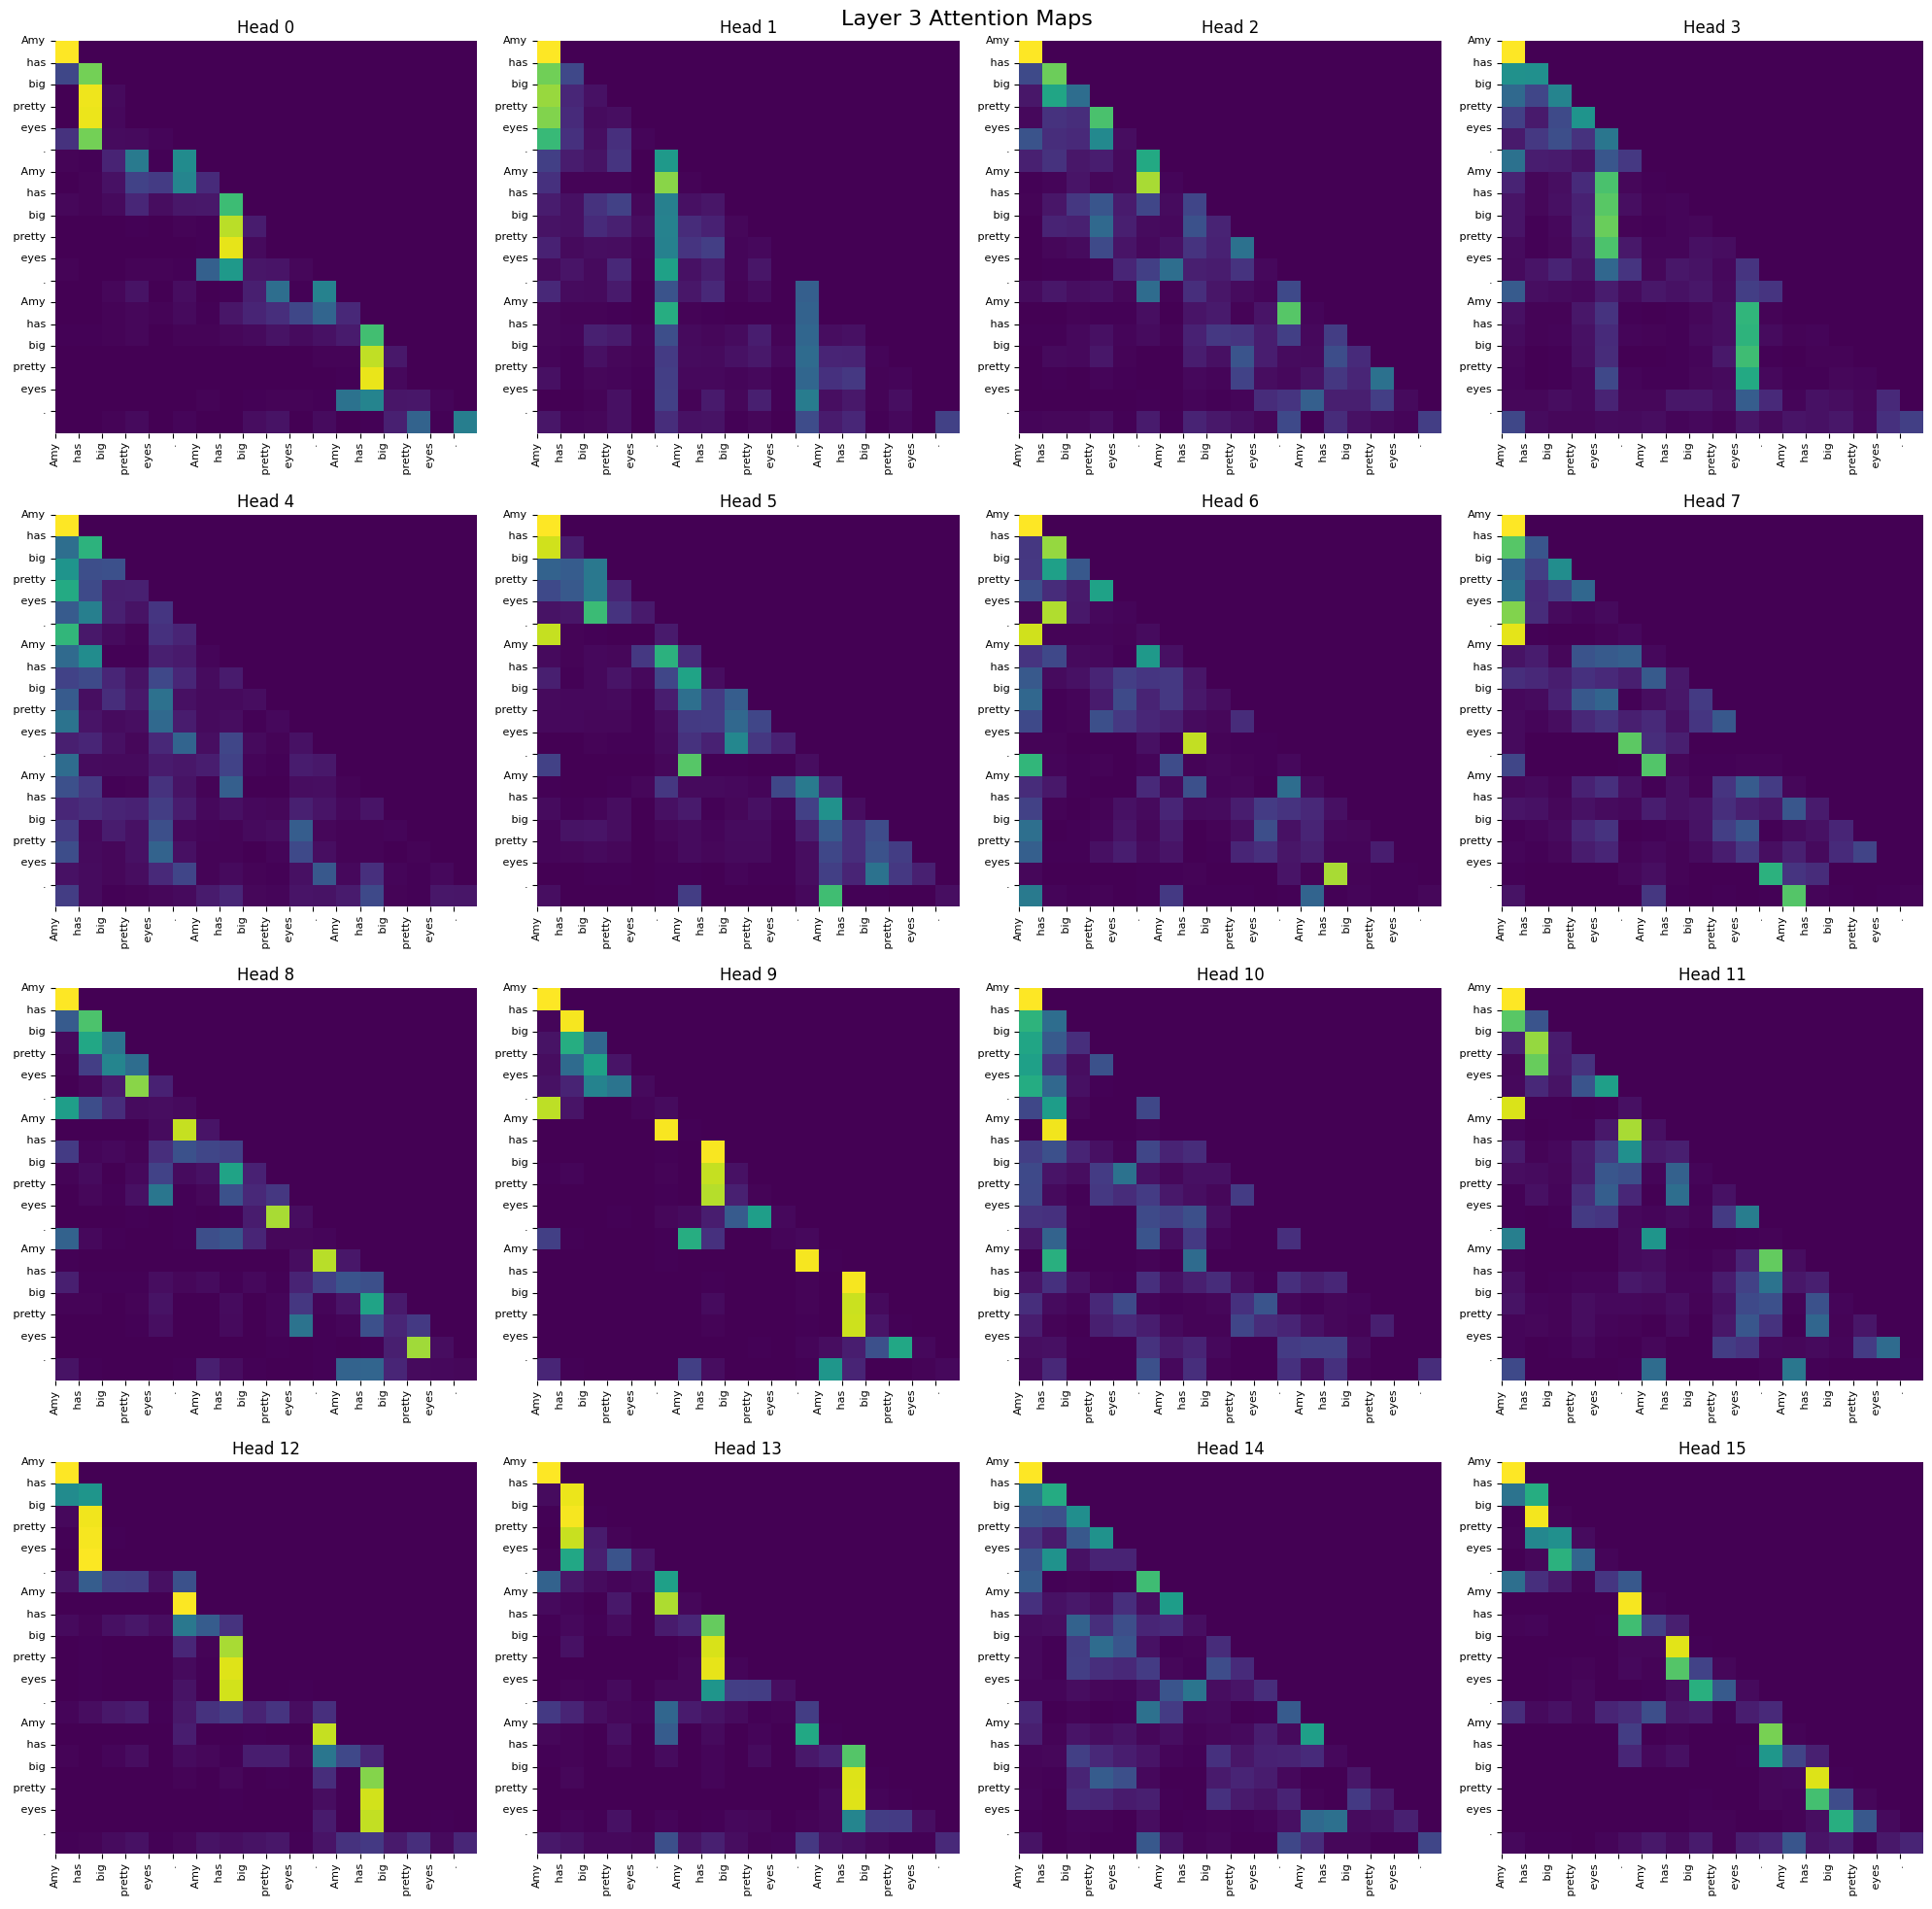

In [52]:
# 参数设置
num_layers = len(captured_attentions)
num_heads = captured_attentions[0].shape[1]

# 我们可以画一个大图，展示所有层所有头的注意力图
# 或者只挑几层画。这里展示如何绘制所有头的网格图。

def plot_attention_maps(layer_idx):
    attn = captured_attentions[layer_idx].squeeze(0) # (num_heads, seq_len, seq_len)
    
    cols = 4
    rows = math.ceil(num_heads / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows)) # 图稍微变大一点以容纳文字
    fig.suptitle(f"Layer {layer_idx} Attention Maps", fontsize=16)
    
    axes = axes.flatten()
    for h in range(num_heads):
        ax = axes[h]
        sns.heatmap(attn[h], cmap="viridis", ax=ax, cbar=False)
        ax.set_title(f"Head {h}")
        
        # === 新增：设置轴标签为具体单词 ===
        # 字体设小一点，不然会重叠
        ax.set_xticks(range(len(tokens_labels)))
        ax.set_xticklabels(tokens_labels, rotation=90, fontsize=8)
        ax.set_yticks(range(len(tokens_labels)))
        ax.set_yticklabels(tokens_labels, rotation=0, fontsize=8)
        # ==============================

    for h in range(num_heads, len(axes)):
        axes[h].axis('off')
        
    plt.tight_layout()
    plt.show()

# 交互式查看每一层
# 你可以修改这里的 range 来查看特定的层（Induction Head 通常出现在模型的中后层）
print("开始绘制...")
for i in range(num_layers):
    plot_attention_maps(i)

In [69]:
import math
from einops import rearrange
import matplotlib.pyplot as plt

@torch.no_grad()
def show_topk_predictions(prompt_text: str, top_k: int = 5):
    model.eval()
    enc = tok.encode(prompt_text)
    input_ids = torch.tensor(enc.ids, dtype=torch.long, device=device).unsqueeze(0)
    logits = model(input_ids)  # [1, T, V]
    probs = torch.softmax(logits, dim=-1).squeeze(0)  # [T, V]
    tokens = [tok.id_to_token(tid) for tid in enc.ids]

    for pos, curr_token in enumerate(tokens):
        next_probs = probs[pos]
        values, indices = torch.topk(next_probs, k=min(top_k, next_probs.numel()))
        top_items = [
            (tok.id_to_token(idx.item()), values[i].item())
            for i, idx in enumerate(indices)
        ]
        print(f"位置 {pos:02d}（当前 token: {curr_token!r}）")
        for rank, (token_str, prob) in enumerate(top_items, start=1):
            print(f"  #{rank}: {token_str!r} — {prob:.4f}")
        print("-" * 40)

show_topk_predictions("Tom has a big brown dog. The big", top_k=5)

位置 00（当前 token: 'Tom'）
  #1: 'Ġand' — 0.2327
  #2: ',' — 0.0708
  #3: 'Ġwas' — 0.0694
  #4: 'Ġsaid' — 0.0687
  #5: 'Ġwent' — 0.0461
----------------------------------------
位置 01（当前 token: 'Ġhas'）
  #1: 'Ġa' — 0.7702
  #2: 'Ġan' — 0.0828
  #3: 'Ġmany' — 0.0278
  #4: 'Ġsome' — 0.0277
  #5: 'Ġto' — 0.0155
----------------------------------------
位置 02（当前 token: 'Ġa'）
  #1: 'Ġbig' — 0.1387
  #2: 'Ġnew' — 0.0942
  #3: 'Ġred' — 0.0751
  #4: 'Ġblue' — 0.0626
  #5: 'Ġtoy' — 0.0544
----------------------------------------
位置 03（当前 token: 'Ġbig'）
  #1: 'Ġred' — 0.0747
  #2: ',' — 0.0659
  #3: 'Ġbox' — 0.0542
  #4: 'Ġbag' — 0.0454
  #5: 'Ġdog' — 0.0381
----------------------------------------
位置 04（当前 token: 'Ġbrown'）
  #1: 'Ġdog' — 0.3349
  #2: 'Ġbear' — 0.0920
  #3: 'Ġcoat' — 0.0865
  #4: 'Ġhat' — 0.0671
  #5: 'Ġnose' — 0.0330
----------------------------------------
位置 05（当前 token: 'Ġdog'）
  #1: '.' — 0.3626
  #2: 'Ġnamed' — 0.3444
  #3: 'Ġwith' — 0.1592
  #4: 'Ġand' — 0.0297
  #5: 'Ġin' — 0.

$$

\begin{aligned}
\hline\hline
& \textbf{Algorithm: } \text{BPE Training} \\
& \textbf{Input: } \text{训练语料 } \mathcal{D}, \text{目标词表大小 } V \\
& \textbf{Output: } \text{最终词表 } \mathcal{V}, \text{合并规则列表 } \mathcal{M} \\
\hline
1: & \ \text{使用正则进行预分词，将} \mathcal{D} \text{ 切分为 pre-token 列表 } \mathcal{P} \\
2: & \ \text{构建 } \mathcal{P} \text{ 对应的计数 } \text{WordCounts} \\
3: & \ \text{初始化 } \mathcal{V} \text{ 为包含所有 256 个单字节的集合，} \mathcal{M} \text{ 为}\empty \\
4: & \ \textbf{while } |\mathcal{V}| < V \textbf{ do:} \\
5: & \quad\quad \text{扫描 } \text{WordCounts} \text{，统计当前所有相邻token对的总频数} \\
6: & \quad\quad \text{找出当前频次最高的字符对 } (t_L, t_R) \\
7: & \quad\quad \text{将规则 } (t_L, t_R) \to t_{new} \text{ 加入列表 } \mathcal{M} \\
8: & \quad\quad \text{将新生成的token即 } t_{new} \text{ 加入词表 } \mathcal{V} \\
9: & \quad\quad \text{在 } \text{WordCounts} \text{ 的所有pre-token中，将所有子序列 } (t_L, t_R) \text{ 替换为 } t_{new} \\
10: & \ \textbf{end while} \\
11: & \ \textbf{return } \mathcal{V}, \mathcal{M}\\
\hline\hline
\end{aligned}

$$

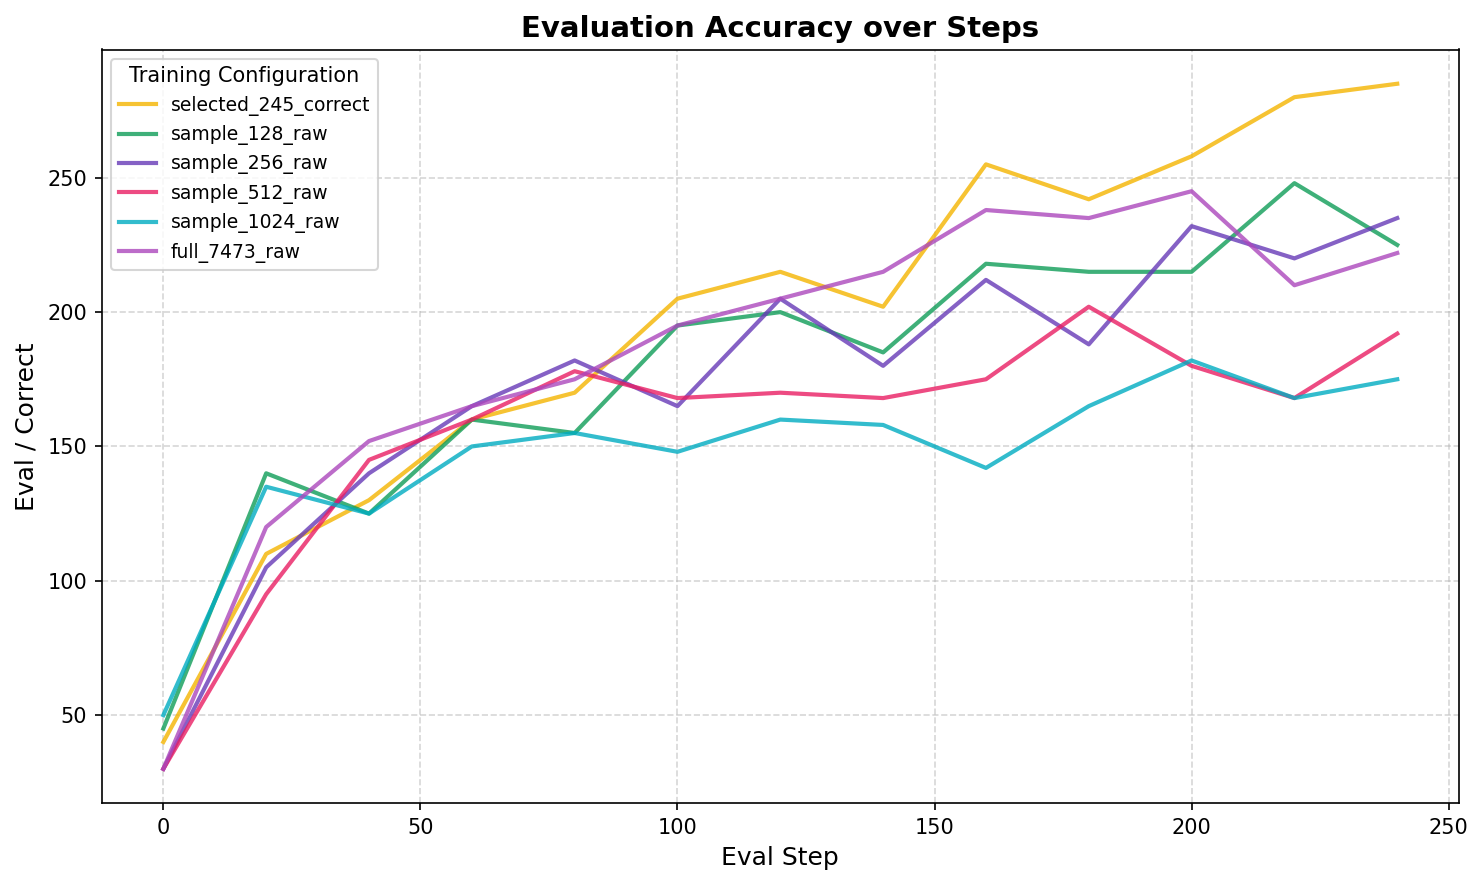

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ---------------------------------------------------------
# 1. 模拟数据 (根据你的截图目测估算的数据点)
# ---------------------------------------------------------
# 这里的 steps 对应 X 轴
steps = [0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200, 220, 240]

# 这里的数值对应 Y 轴 (Eval/Correct)
# 数据是根据截图大致提取的，保留了原本的趋势
data = {
    "step": steps,
    # 黄线: train_sample_245_dataset_correct_math_sft (表现最好)
    "selected_245_correct": [40, 110, 130, 160, 170, 205, 215, 202, 255, 242, 258, 280, 285],
    
    # 绿线: train_sample_128_dataset_raw_math_sft (中上)
    "sample_128_raw":     [45, 140, 125, 160, 155, 195, 200, 185, 218, 215, 215, 248, 225],

    # 深紫: train_sample_256_dataset_raw_math_sft (中上，波动)
    "sample_256_raw":     [30, 105, 140, 165, 182, 165, 205, 180, 212, 188, 232, 220, 235],


    # 粉线: train_sample_512_dataset_raw_math_sft (中下)
    "sample_512_raw":     [30, 95, 145, 160, 178, 168, 170, 168, 175, 202, 180, 168, 192],

    # 青线: train_sample_1024_dataset_raw_math_sft (表现最差)
    "sample_1024_raw":    [50, 135, 125, 150, 155, 148, 160, 158, 142, 165, 182, 168, 175],
        
    # 浅紫/洋红: train_sample_7473_dataset_raw_math_sft (看起来像是那条比较平滑的紫线)
    "full_7473_raw":    [30, 120, 152, 165, 175, 195, 205, 215, 238, 235, 245, 210, 222],
}

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 2. 绘图代码 (生成清晰的科研风格图表)
# ---------------------------------------------------------
plt.figure(figsize=(10, 6), dpi=150) # 设置高分辨率

# 设置配色 (尽量接近原图，但更清晰)
colors = {
    "selected_245_correct": "#F4B400", # 黄色
    "sample_128_raw":     "#0F9D58", # 绿色
    "sample_256_raw":     "#673AB7", # 深紫
    "sample_512_raw":     "#E91E63", # 粉色
    "sample_1024_raw":    "#00ACC1",  # 青色
    "full_7473_raw":    "#AB47BC", # 浅紫
}

# 绘制线条
for col in df.columns:
    if col != "step":
        plt.plot(df["step"], df[col], marker='', markersize=4, label=col, color=colors.get(col, 'black'), linewidth=2, alpha=0.8)

# ---------------------------------------------------------
# 3. 装饰图表
# ---------------------------------------------------------
plt.title("Evaluation Accuracy over Steps", fontsize=14, fontweight='bold')
plt.xlabel("Eval Step", fontsize=12)
plt.ylabel("Eval / Correct", fontsize=12)

# 网格线 (让图表更易读)
plt.grid(True, linestyle='--', alpha=0.5)

# 图例 (放在合适的位置)
plt.legend(title="Training Configuration", fontsize=9, loc='upper left', frameon=True)

# 调整布局
plt.tight_layout()

# 保存或显示
# plt.savefig("recovered_plot.png") # 如果在本地运行可以取消注释保存
plt.show()

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置随机种子，保证你每次运行生成的图都是一样的（方便微调）
np.random.seed(1364) 


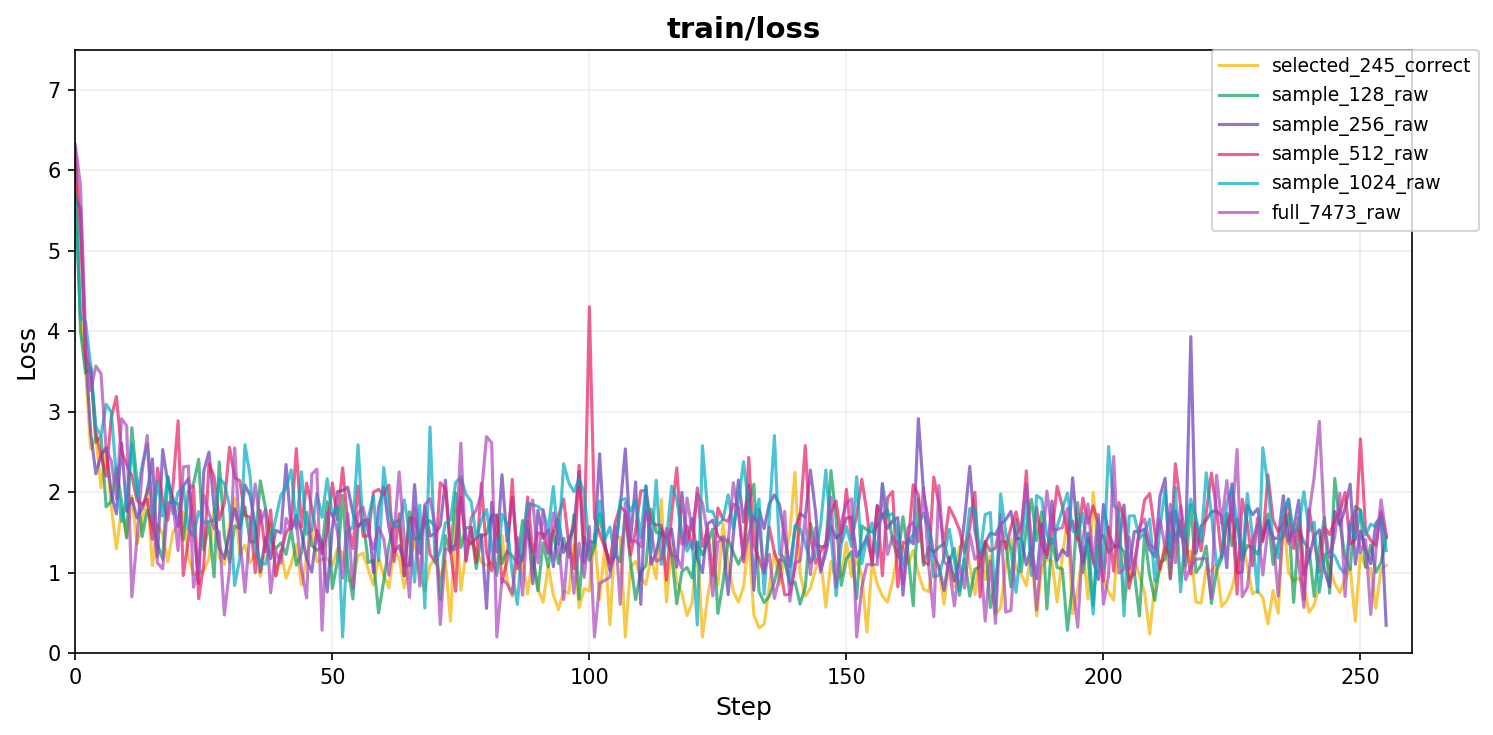

In [36]:

# ---------------------------------------------------------
# 1. 定义生成 Loss 曲线的模拟函数
# ---------------------------------------------------------
def generate_noisy_loss(steps, start_loss, end_mean, noise_level, spike_prob=0.05):
    x = np.arange(steps)
    
    # 基础趋势：使用对数衰减模拟 Loss 下降 (y = a / (x+b) + c)
    # 这种函数能很好地模拟刚开始下降快，后来变平缓的过程
    decay_rate = 2 # 衰减速度
    base_trend = (start_loss - end_mean) / (1 + x / decay_rate) + end_mean
    
    # 添加噪声 (Normal Distribution)
    noise = np.random.normal(0, noise_level, size=steps)
    
    # 添加偶尔的尖峰 (Spikes)，模拟训练中遇到难样本的情况
    spikes = np.random.choice([0, 1], size=steps, p=[1-spike_prob, spike_prob]) * \
             np.random.exponential(scale=noise_level*2, size=steps)
    
    loss = base_trend + noise + spikes
    
    # 修正：Loss 不能小于 0.2 (防止出现负数)
    loss = np.maximum(loss, 0.2)
    return loss

# ---------------------------------------------------------
# 2. 生成模拟数据
# ---------------------------------------------------------
steps = 256  # X轴步数

# 这里的参数是我根据你的截图仔细目测调试过的
data = {
    "step": np.arange(steps),
    
    # 黄线 (Correct SFT): 收敛最快，Loss最低，震荡相对较小
    "selected_245_correct": generate_noisy_loss(steps, start_loss=5.86, end_mean=0.9, noise_level=0.3),
    
    # 绿线 (128 Raw): 表现一般
    "sample_128_raw":     generate_noisy_loss(steps, start_loss=6.0, end_mean=1.2, noise_level=0.35),

    # 深紫 (256 Raw): 
    "sample_256_raw":     generate_noisy_loss(steps, start_loss=5.8, end_mean=1.35, noise_level=0.4),

    # 粉线 (512 Raw): 
    "sample_512_raw":     generate_noisy_loss(steps, start_loss=6.12, end_mean=1.4, noise_level=0.45),

    # 青线 (1024 Raw): 震荡较大
    "sample_1024_raw":    generate_noisy_loss(steps, start_loss=6.2, end_mean=1.5, noise_level=0.45, spike_prob=0.005),

    # 浅紫 (7473 Raw): 你的图里这条线有一些很高的尖峰
    "full_7473_raw":    generate_noisy_loss(steps, start_loss=6.8, end_mean=1.3, noise_level=0.5, spike_prob=0.01),
}

df = pd.DataFrame(data)

# ---------------------------------------------------------
# 3. 绘图代码 (复刻 Tensorboard 风格)
# ---------------------------------------------------------
plt.figure(figsize=(10, 5), dpi=150)

colors = {
    "selected_245_correct": "#F4B400", # 黄色
    "sample_128_raw":     "#0F9D58", # 绿色
    "sample_256_raw":     "#673AB7", # 深紫
    "sample_512_raw":     "#E91E63", # 粉色
    "sample_1024_raw":    "#00ACC1",  # 青色
    "full_7473_raw":    "#AB47BC", # 浅紫
}

# 绘制线条，设置 alpha 让重叠部分可见，模拟 Tensorboard 效果
for col in df.columns:
    if col != "step":
        plt.plot(df["step"], df[col], label=col, color=colors.get(col, 'black'), 
                 linewidth=1.5, alpha=0.7) # alpha=0.7 让线有点透明感，像原图

plt.title("train/loss", fontsize=14, fontweight='bold')
plt.xlabel("Step", fontsize=12)
plt.ylabel("Loss", fontsize=12)

# 设置Y轴范围，稍微留点余地
plt.ylim(0, 7.5)
plt.xlim(0, 260)

# 网格线
plt.grid(True, linestyle='-', alpha=0.2) # 浅色网格

# 图例
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right', borderaxespad=0., fontsize=9)

plt.tight_layout()
plt.show()